# Experimento 5 — Efecto del término HSIC (beta) en KAN/KAAM sobre Sachs

Extiende `notebooks/alejandro/sachs_analysis.ipynb`: en vez de solo comparar kan/kaam/dbcm/flow con
`loss='mse'`, se entrena también kan y kaam con la loss híbrida
`train_loss = alpha_weight * NMSE + beta_weight * nHSIC` (`src/models/kan.py`, `custom_fit`), barriendo
`beta_weight` de 0.1 a 0.8 (`alpha_weight = 1 - beta_weight`). El barrido (y el punto `Beta=0`, MSE
puro) se repite sobre **20 semillas** distintas (`beta_sweep_seeds`, ver celda "Barrido de beta"),
para poder graficar `RF Acc` frente a `Beta` como media ± std en vez de un único punto. Se selecciona
la beta óptima (mínimo `rf_acc_obs` medio sobre esas 20 semillas) por separado para kan y para kaam, y
esos dos modelos (`kan_hsic`, `kaam_hsic`) se añaden a la comparación final junto a `kan`, `kaam`,
`dbcm` y `flow`. **ANM queda excluido.**

Importante: el barrido de 20 semillas es independiente del resto del notebook. Los 6 modelos finales
(y por tanto las secciones de distribuciones, fórmulas KAAM y ejemplos de ATE) se siguen entrenando y
evaluando con una única semilla fija (`seed=42`, celda "Generate the SACHS dataset"), exactamente igual
que antes -- no cambian.

No se realiza búsqueda de hiperparámetros: se usan directamente los mejores hiperparámetros ya
encontrados previamente para kan/kaam/dbcm/flow sobre Sachs (fijados en la celda de hiperparámetros).

In [1]:
import os
import sys
import pickle
import time
from copy import deepcopy

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import numpy as np
import pandas as pd
import networkx as nx
import sympy
from joblib import Parallel, delayed
from tqdm import tqdm
from tabulate import tabulate
import matplotlib.pyplot as plt

from dowhy import gcm

from models.factory import create_model_from_graph
from models.flow import causalflow_model
from models.kan import symbolic_kan_regressor
from utils.metrics import mmd, rf
from utils.paths import get_experiment_paths
from datasets.sachs import (
    ExperimentationModel,
    get_structural_equations_sachs,
    graph_sachs,
    noises_distr,
)

n_jobs = 16  # nucleos disponibles: usado tanto para el barrido de beta como para las evaluaciones intervencionales


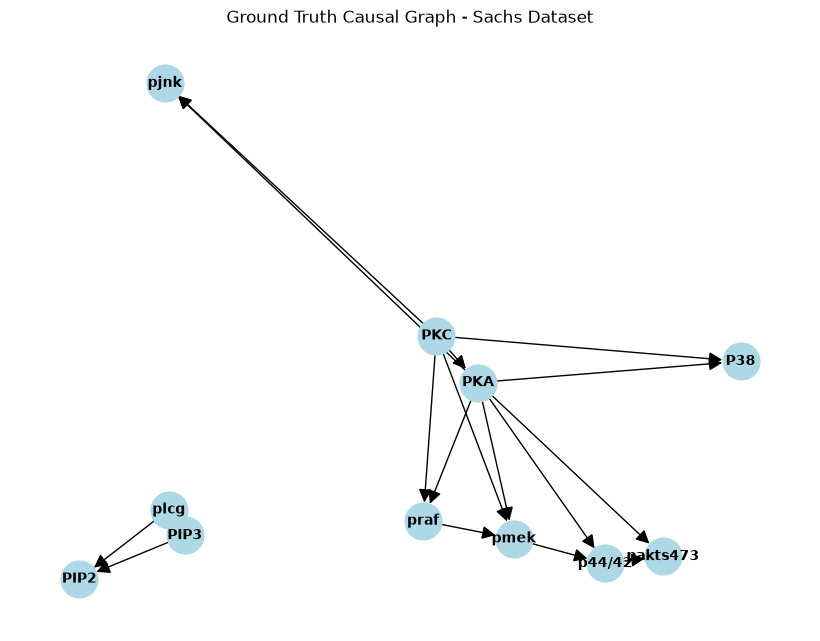

In [2]:
# Show the ground truth graph
plt.figure(figsize=(8, 6))
pos = nx.spring_layout(graph_sachs, seed=42)
nx.draw(graph_sachs, pos, with_labels=True, node_size=700, node_color='lightblue', font_size=10, font_weight='bold', arrowsize=20)
plt.title("Ground Truth Causal Graph - Sachs Dataset")
plt.show()


In [3]:
# Verificacion de que todos los nodos del grafo Sachs son continuos (ver src/datasets/sachs.py):
# el ruido de cada nodo es ScipyDistribution sobre scipy.stats.norm, y las ecuaciones estructurales
# (basadas en silu) producen salidas reales -- no hay ningun nodo discreto/categorico.
print("Verificacion de continuidad de las variables del grafo Sachs:\n")
for node in sorted(graph_sachs.nodes):
    dist = noises_distr[node]
    print(f"  {node:10s} -> ruido: {type(dist).__name__} sobre scipy.stats.norm (continua)")

all_continuous = all(isinstance(noises_distr[n], gcm.ScipyDistribution) for n in graph_sachs.nodes)
print(f"\nTotal de nodos: {graph_sachs.number_of_nodes()}")
print(f"Todos los nodos son continuos: {all_continuous}")
assert all_continuous, "Se esperaba que todos los nodos de Sachs fuesen continuos"


Verificacion de continuidad de las variables del grafo Sachs:

  P38        -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  PIP2       -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  PIP3       -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  PKA        -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  PKC        -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  p44/42     -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  pakts473   -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  pjnk       -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  plcg       -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  pmek       -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)
  praf       -> ruido: ScipyDistribution sobre scipy.stats.norm (continua)

Total de nodos: 11
Todos los nodos son continuos: True


100%|██████████| 11/11 [00:03<00:00,  2.83it/s]


Train set shape: (300, 11), Eval set shape: (300, 11), Num of interventions: 660


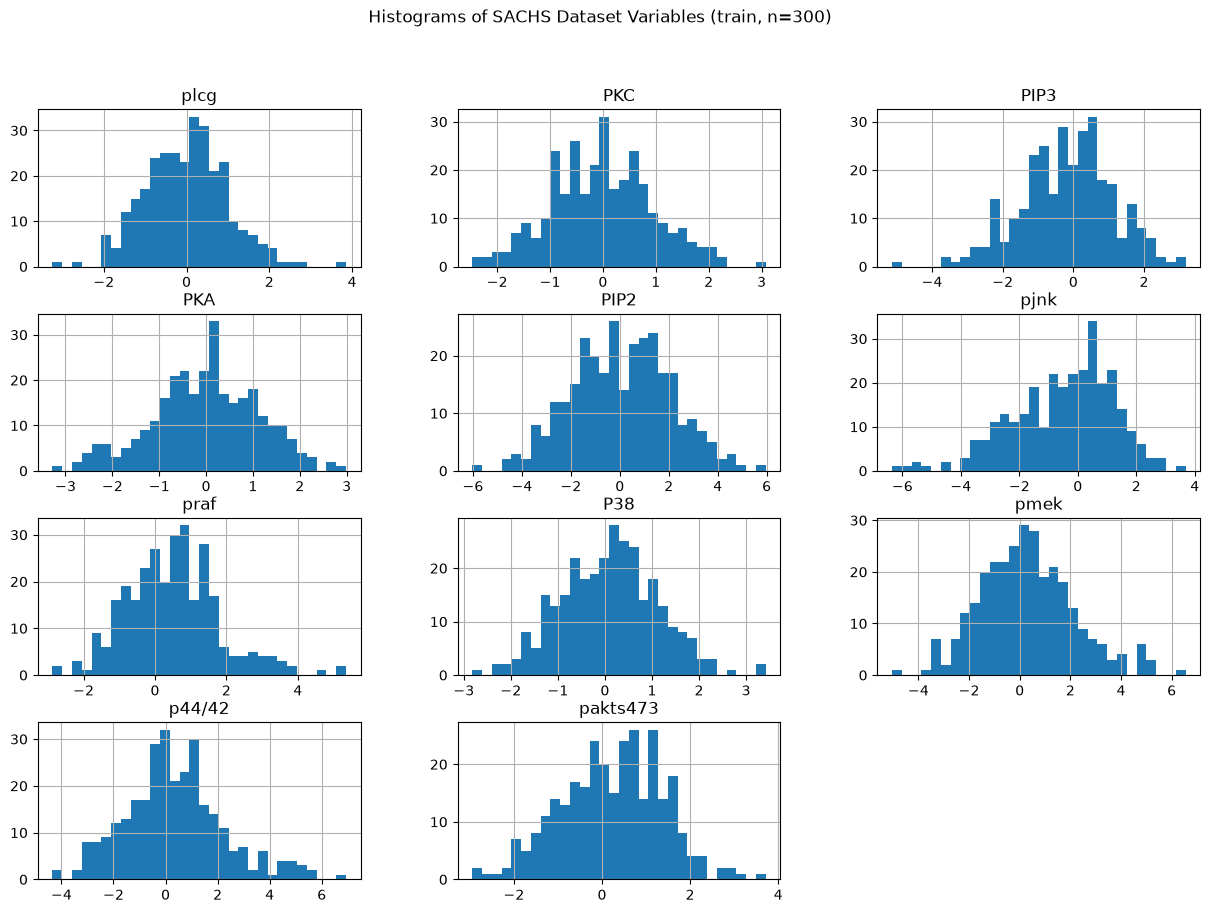

In [4]:
# Generate the SACHS dataset using the structural equations defined in datasets/sachs.py
num_samples_train = 300
num_samples_eval = 300
structural_equations = get_structural_equations_sachs()
sachs_generator = ExperimentationModel(graph_sachs, "sachs_hsic", structural_equations['additive'], noises_distr)
np.random.seed(42)  # Set seed for repeatability
factual_train, noise_train = sachs_generator.sample(num_samples_train)
factual_eval, noise_eval = sachs_generator.sample(num_samples_eval)

cf_min_val = -3
cf_max_val = 3
cf_step = 0.1
cf_vector_values = np.arange(cf_min_val, cf_max_val, cf_step)
inter_vector = []
for node in tqdm(factual_eval.columns):
    for value in list(cf_vector_values):
        inter_vector.append((node, value, sachs_generator.get_counterfactuals({node: lambda x: value}, noise_eval)[factual_eval.columns]))

print(f'Train set shape: {factual_train.shape}, Eval set shape: {factual_eval.shape}, Num of interventions: {len(inter_vector)}')

paths = get_experiment_paths('sachs_hsic')
results_bdir = str(paths.root)
images_dir = str(paths.images)
samples_dir = str(paths.samples)
figures_dir = str(paths.figures)
data_dir = str(paths.data)

factual_train.to_csv(os.path.join(data_dir, 'sachs_factual_train.csv'), index=False)
factual_eval.to_csv(os.path.join(data_dir, 'sachs_factual_eval.csv'), index=False)

with open(os.path.join(data_dir, 'sachs_interventions_eval.pkl'), 'wb') as f:
    pickle.dump(inter_vector, f, protocol=pickle.HIGHEST_PROTOCOL)

# Show a histogram of all the variables in the dataset (train)
factual_train.hist(bins=30, figsize=(15, 10))
plt.suptitle("Histograms of SACHS Dataset Variables (train, n=300)")
plt.show()


## Hiperparametros fijos (best params ya encontrados)

Sin busqueda de hiperparametros: se usan directamente los mejores hiperparametros ya localizados
para kan, kaam, dbcm y flow sobre Sachs (salida de una busqueda previa con `get_best_hyperparams`,
limpiada de las claves de diagnostico `mmd`/`rf_acc` que no son argumentos validos de los
constructores). `kan_best_params` y `kaam_best_params` son identicos salvo en `pakts473`, donde kan
usa una configuracion multicapa (`hidden_dim=5`, `mult_kan=True`) y kaam se mantiene monocapa
(`hidden_dim=0`, `mult_kan=False`).

In [5]:
kaam_best_params = {
    "PIP3": dict(hidden_dim=0, batch_size=-1, grid=1, k=5, seed=0, lr=0.001, early_stop=True,
                 steps=10000, lamb=0.1, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                 try_gpu=False, loss="mse"),
    "PIP2": dict(hidden_dim=0, batch_size=-1, grid=5, k=5, seed=0, lr=0.0001, early_stop=True,
                 steps=10000, lamb=0.001, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                 try_gpu=False, loss="mse"),
    "PKA": dict(hidden_dim=0, batch_size=-1, grid=10, k=1, seed=0, lr=0.01, early_stop=True,
                steps=10000, lamb=0.001, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                try_gpu=False, loss="mse"),
    "pjnk": dict(hidden_dim=0, batch_size=-1, grid=10, k=1, seed=0, lr=0.01, early_stop=True,
                 steps=10000, lamb=0.001, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                 try_gpu=False, loss="mse"),
    "P38": dict(hidden_dim=0, batch_size=-1, grid=1, k=5, seed=0, lr=0.001, early_stop=True,
                steps=10000, lamb=0.1, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                try_gpu=False, loss="mse"),
    "praf": dict(hidden_dim=0, batch_size=-1, grid=5, k=5, seed=0, lr=0.01, early_stop=True,
                 steps=10000, lamb=0.1, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                 try_gpu=False, loss="mse"),
    "pmek": dict(hidden_dim=0, batch_size=-1, grid=5, k=5, seed=0, lr=0.01, early_stop=True,
                 steps=10000, lamb=0.1, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                 try_gpu=False, loss="mse"),
    "p44/42": dict(hidden_dim=0, batch_size=-1, grid=5, k=5, seed=0, lr=0.0001, early_stop=True,
                   steps=10000, lamb=0.001, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                   try_gpu=False, loss="mse"),
    "pakts473": dict(hidden_dim=0, batch_size=-1, grid=10, k=1, seed=0, lr=0.001, early_stop=True,
                      steps=10000, lamb=0.001, lamb_entropy=0.1, sparse_init=False, mult_kan=False,
                      try_gpu=False, loss="mse"),
}

kan_best_params = deepcopy(kaam_best_params)
kan_best_params["pakts473"] = dict(hidden_dim=5, batch_size=-1, grid=10, k=10, seed=0, lr=0.01,
                                    early_stop=True, steps=10000, lamb=0.001, lamb_entropy=0.1,
                                    sparse_init=False, mult_kan=True, try_gpu=False, loss="mse")

dbcm_best_params = dict(num_epochs=500, lr=0.001, batch_size=128, hidden_dim=64)

flow_best_params = dict(flow_type="CausalMAF", hidden_dims=(64, 64, 64), base_lr=0.01,
                         early_stopping_patience=30, scheduler="plateau", batch_size=256,
                         train_val_split=(0.8, 0.2), max_epochs=1000, device="cpu", bins=4)


def with_hybrid_loss(base_params, beta):
    """Devuelve una copia de base_params con loss='hybrid' y los pesos alpha/beta indicados."""
    params = deepcopy(base_params)
    for node in params:
        params[node] = {**params[node], "loss": "hybrid", "beta_weight": beta, "alpha_weight": 1 - beta}
    return params


betas = [round(0.1 * i, 1) for i in range(1, 9)]  # 0.1 .. 0.8
print(f"Betas a evaluar: {betas}")


Betas a evaluar: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]


## Barrido de beta (kan y kaam por separado, 20 semillas, paralelizado)

Para cada combinación (familia, beta, semilla) se entrena el modelo con `loss='hybrid'` (o `loss='mse'`
para el punto `Beta=0`) y se evalúa solo con métricas observacionales (`mmd_obs`, `rf_acc_obs`) --
repetir la evaluación intervencional/contrafactual completa para las 360 combinaciones sería mucho más
caro sin aportar a la selección, que solo usa estas dos métricas observacionales.

Diseño: el conjunto de **evaluación** es siempre el `factual_eval` fijo definido en la celda "Generate
the SACHS dataset" (igual para las 20 semillas, para que sean comparables entre sí); lo único que varía
por semilla es el conjunto de **entrenamiento** (`factual_train_por_seed`), generado aquí una vez por
semilla reutilizando el mismo `sachs_generator`. `Beta=0` (MSE puro) se entrena con las mismas 20
semillas -- ya no se reutiliza el `kan`/`kaam` de la sección de los 6 modelos finales (esos siguen
usando solo `seed=42`) -- para tener también su propia media ± std, comparable con el resto del barrido.

Se paraleliza a `n_jobs=16`: (2 familias x 8 betas x 20 semillas) + (2 familias x 20 semillas, para
`Beta=0`) = 320 + 40 = 360 combinaciones en total (~22.5x más que el barrido original de una sola
semilla, que solo cubría las 16 combinaciones familia x beta).

In [6]:
beta_sweep_seeds = np.array([42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
                              52, 53, 54, 55, 56, 57, 58, 59, 60, 61])  # 20 semillas

# Un conjunto de entrenamiento distinto por semilla (mismo tamano que el factual_train de
# seed=42, 300 muestras); reutiliza el mismo sachs_generator, la evaluacion sigue siendo
# siempre el factual_eval fijo definido antes.
factual_train_por_seed = {}
for seed in beta_sweep_seeds:
    np.random.seed(int(seed))
    factual_train_por_seed[int(seed)], _ = sachs_generator.sample(num_samples_train)


def train_and_eval_run(family, beta, seed):
    """beta=None entrena el baseline (loss='mse'); beta en (0, 1) entrena con loss='hybrid'."""
    base = kan_best_params if family == "kan" else kaam_best_params
    params = deepcopy(base) if beta is None else with_hybrid_loss(base, beta)
    model = create_model_from_graph(graph_sachs, family, params=params)

    t0 = time.time()
    gcm.fit(model, data=factual_train_por_seed[seed])
    training_time = time.time() - t0

    obs_samples = gcm.draw_samples(model, num_samples=len(factual_eval))
    obs_samples = obs_samples[factual_eval.columns]
    metrics = {
        "mmd_obs": mmd(factual_eval.to_numpy(), obs_samples.to_numpy()),
        "rf_acc_obs": rf(factual_eval.to_numpy(), obs_samples.to_numpy()),
        "training_time": training_time,
    }
    return family, beta, seed, metrics


tareas = [(family, None, int(seed)) for family in ["kan", "kaam"] for seed in beta_sweep_seeds]
tareas += [(family, beta, int(seed)) for family in ["kan", "kaam"] for beta in betas for seed in beta_sweep_seeds]

out = Parallel(n_jobs=n_jobs, verbose=5)(delayed(train_and_eval_run)(family, beta, seed) for family, beta, seed in tareas)

resultados_por_semilla = {"kan": {}, "kaam": {}}
for family, beta, seed, metrics in out:
    resultados_por_semilla[family].setdefault(beta, {})[seed] = metrics

# beta=None (Beta=0, MSE puro) y beta in betas (barrido hybrid), separados para claridad.
beta0_sweep_results_por_semilla = {family: resultados_por_semilla[family][None] for family in ["kan", "kaam"]}
beta_sweep_results_por_semilla = {family: {b: resultados_por_semilla[family][b] for b in betas} for family in ["kan", "kaam"]}

# Agregado (media sobre las 20 semillas) con el MISMO esquema de antes (una fila por beta,
# sin dimension de semilla), para que la seleccion de la Beta optima (celda siguiente) y
# Resumen_Sachs.ipynb sigan funcionando sin cambios -- ahora la media es sobre 20 semillas
# en vez de un unico punto.
beta_sweep_results = {"kan": {}, "kaam": {}}
for family in ["kan", "kaam"]:
    for beta in betas:
        valores = list(beta_sweep_results_por_semilla[family][beta].values())
        beta_sweep_results[family][beta] = {
            "mmd_obs": float(np.mean([v["mmd_obs"] for v in valores])),
            "rf_acc_obs": float(np.mean([v["rf_acc_obs"] for v in valores])),
            "training_time": float(np.mean([v["training_time"] for v in valores])),
        }

for family in ["kan", "kaam"]:
    with open(os.path.join(data_dir, f"sachs_beta_sweep_{family}.pkl"), "wb") as f:
        pickle.dump(beta_sweep_results[family], f, protocol=pickle.HIGHEST_PROTOCOL)
    with open(os.path.join(data_dir, f"sachs_beta_sweep_{family}_por_semilla.pkl"), "wb") as f:
        pickle.dump(beta_sweep_results_por_semilla[family], f, protocol=pickle.HIGHEST_PROTOCOL)
    with open(os.path.join(data_dir, f"sachs_beta0_sweep_{family}_por_semilla.pkl"), "wb") as f:
        pickle.dump(beta0_sweep_results_por_semilla[family], f, protocol=pickle.HIGHEST_PROTOCOL)

for family in ["kan", "kaam"]:
    print(f"\nBarrido de beta para {family} (media +- std sobre {len(beta_sweep_seeds)} semillas):")
    valores0 = list(beta0_sweep_results_por_semilla[family].values())
    rows = [[
        0.0,
        f"{np.mean([v['mmd_obs'] for v in valores0]):.4f} +- {np.std([v['mmd_obs'] for v in valores0]):.4f}",
        f"{np.mean([v['rf_acc_obs'] for v in valores0]):.4f} +- {np.std([v['rf_acc_obs'] for v in valores0]):.4f}",
    ]]
    for b in betas:
        valores = list(beta_sweep_results_por_semilla[family][b].values())
        rows.append([
            b,
            f"{np.mean([v['mmd_obs'] for v in valores]):.4f} +- {np.std([v['mmd_obs'] for v in valores]):.4f}",
            f"{np.mean([v['rf_acc_obs'] for v in valores]):.4f} +- {np.std([v['rf_acc_obs'] for v in valores]):.4f}",
        ])
    print(tabulate(rows, headers=["beta", "mmd_obs (media +- std)", "rf_acc_obs (media +- std)"], tablefmt="fancy_grid"))


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  40 tasks      | elapsed:  8.8min
[Parallel(n_jobs=16)]: Done 130 tasks      | elapsed: 57.5min
[Parallel(n_jobs=16)]: Done 256 tasks      | elapsed: 121.0min
c:\Users\aarna\miniconda3\envs\TFM_clau\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(



Barrido de beta para kan (media +- std sobre 20 semillas):
╒════════╤══════════════════════════╤═════════════════════════════╕
│   beta │ mmd_obs (media +- std)   │ rf_acc_obs (media +- std)   │
╞════════╪══════════════════════════╪═════════════════════════════╡
│    0   │ 0.0071 +- 0.0016         │ 0.5262 +- 0.0185            │
├────────┼──────────────────────────┼─────────────────────────────┤
│    0.1 │ 0.0071 +- 0.0016         │ 0.5258 +- 0.0123            │
├────────┼──────────────────────────┼─────────────────────────────┤
│    0.2 │ 0.0072 +- 0.0017         │ 0.5179 +- 0.0183            │
├────────┼──────────────────────────┼─────────────────────────────┤
│    0.3 │ 0.0072 +- 0.0017         │ 0.5196 +- 0.0208            │
├────────┼──────────────────────────┼─────────────────────────────┤
│    0.4 │ 0.0073 +- 0.0018         │ 0.5300 +- 0.0201            │
├────────┼──────────────────────────┼─────────────────────────────┤
│    0.5 │ 0.0074 +- 0.0019         │ 0.5308 +- 0.0236  

[Parallel(n_jobs=16)]: Done 360 out of 360 | elapsed: 171.9min finished


In [7]:
# Seleccion de la beta optima por familia: la que minimiza rf_acc_obs (beta=0/baseline mse no es candidata)
# El grafico del barrido (incluyendo el punto beta=0) se genera mas abajo, tras calcular el baseline mse
# de kan/kaam en la celda de entrenamiento de los 6 modelos finales.
beta_opt = {family: min(betas, key=lambda b: beta_sweep_results[family][b]["rf_acc_obs"]) for family in ["kan", "kaam"]}
print(f"Beta optima (minimo rf_acc_obs) para kan:  {beta_opt['kan']}")
print(f"Beta optima (minimo rf_acc_obs) para kaam: {beta_opt['kaam']}")

Beta optima (minimo rf_acc_obs) para kan:  0.2
Beta optima (minimo rf_acc_obs) para kaam: 0.3


## Entrenamiento y evaluacion completa de los 6 modelos finales

`kan` y `kaam` con los mejores hiperparametros (`loss='mse'`), `kan_hsic`/`kaam_hsic` con esos mismos
hiperparametros pero `loss='hybrid'` en la beta optima encontrada arriba, y `dbcm`/`flow` con sus
mejores hiperparametros. **ANM no se entrena ni se evalua.**

In [8]:
model_names = ['kan', 'kaam', 'kan_hsic', 'kaam_hsic', 'dbcm', 'flow']


def get_model_family_and_params(model_name):
    if model_name == 'kan':
        return 'kan', deepcopy(kan_best_params)
    if model_name == 'kaam':
        return 'kaam', deepcopy(kaam_best_params)
    if model_name == 'kan_hsic':
        return 'kan', with_hybrid_loss(kan_best_params, beta_opt['kan'])
    if model_name == 'kaam_hsic':
        return 'kaam', with_hybrid_loss(kaam_best_params, beta_opt['kaam'])
    if model_name == 'dbcm':
        return 'dbcm', deepcopy(dbcm_best_params)
    raise ValueError(f"Unexpected model_name: {model_name}")


for model_name in model_names:
    # Create and fit model
    if model_name == 'flow':
        model = causalflow_model(graph_sachs, deepcopy(flow_best_params))
        t = time.time()
        model.fit(data=factual_train)
        training_time = time.time() - t
    else:
        family, params = get_model_family_and_params(model_name)
        model = create_model_from_graph(graph_sachs, family, params=params)
        t = time.time()
        gcm.fit(model, data=factual_train)
        training_time = time.time() - t

    # Evaluate the model
    results = {'training_time': training_time, 'model': model_name}
    np.random.seed(42)  # Set the seed for reproducibility

    ## Observational evaluation
    if model_name == 'flow':
        obs_samples = model.draw_samples(num_samples=len(factual_eval))
    else:
        obs_samples = gcm.draw_samples(model, num_samples=len(factual_eval))
    obs_samples = obs_samples[factual_eval.columns]  # Ensure the same column order
    obs_samples.to_csv(os.path.join(samples_dir, f"sachs_obs_samples_{model_name}.csv"), index=False)
    results['mmd_obs_avg'] = mmd(factual_eval.to_numpy(), obs_samples.to_numpy())
    results['rf_acc_obs_avg'] = rf(factual_eval.to_numpy(), obs_samples.to_numpy())

    ## Interventional and counterfactual evaluation
    def evaluate_cf(node, value, cf_eval, model=model, model_name=model_name):
        if model_name == 'flow':
            int_samples = model.interventional_samples({node: lambda x: value}, num_samples_to_draw=len(factual_eval))
            cf_estimates = model.counterfactual_samples({node: lambda x: value}, factual_samples=factual_eval)
        else:
            int_samples = gcm.interventional_samples(model, {node: lambda x: value}, num_samples_to_draw=len(factual_eval))
            cf_estimates = gcm.counterfactual_samples(model, {node: lambda x: value}, observed_data=factual_eval)
        int_samples = int_samples[factual_eval.columns]  # Ensure the same column order
        cf_estimates = cf_estimates[factual_eval.columns]
        mmd_int_ = mmd(cf_eval.to_numpy(), int_samples.to_numpy())
        rf_acc_int_ = rf(cf_eval.to_numpy(), int_samples.to_numpy())
        mse_cf_ = np.mean(np.square(cf_eval.to_numpy() - cf_estimates.to_numpy()))
        mae_cf_ = np.mean(np.abs(cf_eval.to_numpy() - cf_estimates.to_numpy()))
        int_samples_vector_ = (node, value, int_samples)
        cf_samples_vector_ = (node, value, cf_estimates)
        return mmd_int_, rf_acc_int_, mse_cf_, mae_cf_, int_samples_vector_, cf_samples_vector_

    out = Parallel(n_jobs=n_jobs)(delayed(evaluate_cf)(node, value, cf_eval) for node, value, cf_eval in inter_vector)
    mmd_int = [v[0] for v in out]
    rf_acc_int = [v[1] for v in out]
    mse_cf = [v[2] for v in out]
    mae_cf = [v[3] for v in out]
    int_samples_vector = [v[4] for v in out]
    cf_samples_vector = [v[5] for v in out]

    with open(os.path.join(data_dir, f'sachs_interventional_eval_{model_name}.pkl'), 'wb') as f:
        pickle.dump(int_samples_vector, f, protocol=pickle.HIGHEST_PROTOCOL)
    with open(os.path.join(data_dir, f'sachs_cf_eval_{model_name}.pkl'), 'wb') as f:
        pickle.dump(cf_samples_vector, f, protocol=pickle.HIGHEST_PROTOCOL)

    results['mmd_int_avg'] = sum(mmd_int) / len(mmd_int)
    results['mmd_int_all'] = mmd_int
    results['rf_acc_int_avg'] = sum(rf_acc_int) / len(rf_acc_int)
    results['rf_acc_int_all'] = rf_acc_int

    results['mse_cf_avg'] = sum(mse_cf) / len(mse_cf)
    results['mse_cf_all'] = mse_cf
    results['mae_cf_avg'] = sum(mae_cf) / len(mae_cf)
    results['mae_cf_all'] = mae_cf

    if model_name in ('kaam', 'kaam_hsic'):
        # Additionally, compute the goodness of fit of the formulas extracted by KAAM
        for node in model.graph.nodes:
            if hasattr(model.causal_mechanism(node), 'prediction_model'):
                x_names = sorted(model.graph.predecessors(node))
                X_eval = factual_eval[x_names].to_numpy()
                Y_eval = factual_eval[[node]].to_numpy()
                kan_object = model.causal_mechanism(node).prediction_model.model
                symb_obj = symbolic_kan_regressor(x_names, [node], model.causal_mechanism(node).prediction_model.hyperparameters['loss'])
                symb_obj.fit(kan_object, X_eval, Y_eval, val_split=0.2, r2_threshold=0.95, show_results=False, save_dir=None)
                Y_pred_formula = symb_obj.predict(X_eval)
                mae = np.mean(np.abs(Y_eval - Y_pred_formula))
                results[f'kaam_formula_{node}'] = symb_obj.get_formula()[0]
                results[f'mae_{node}'] = mae
                if len(x_names) == 1:
                    x_vals = np.linspace(min(X_eval), max(X_eval), 100)
                    y_pred_kaam = model.causal_mechanism(node).prediction_model.predict(x_vals.reshape(-1, 1))
                    y_pred_formula = sympy.lambdify(x_names, results[f'kaam_formula_{node}'])(x_vals)
                    results[f'kaam_pred_{node}'] = y_pred_kaam
                    results[f'formula_pred_{node}'] = y_pred_formula
                    results[f'x_vals_{node}'] = x_vals
        results['mae'] = np.mean([results[f'mae_{node}'] for node in model.graph.nodes if f'mae_{node}' in results])

    # Save the results
    with open(os.path.join(data_dir, f"sachs_results_{model_name}.pkl"), 'wb') as f:
        pickle.dump(results, f, protocol=pickle.HIGHEST_PROTOCOL)

    print(f"[{model_name}] entrenado y evaluado. training_time={training_time:.2f}s, rf_acc_obs={results['rf_acc_obs_avg']:.4f}, mmd_obs={results['mmd_obs_avg']:.4f}")

Fitting causal mechanism of node PIP3:   0%|          | 0/11 [00:00<?, ?it/s]

Using device: cpu


Fitting causal mechanism of node PIP2:  18%|█▊        | 2/11 [00:15<01:09,  7.75s/it]

Early stopping at step 6417
Using device: cpu


Fitting causal mechanism of node PKA:  45%|████▌     | 5/11 [00:57<00:59,  9.98s/it] 

...

Found polynomial of degree 2 for input 1/1 and output 1/1 with r2 0.9940. Total time: 0.00s, Iteration time: 0.00s, Average time per output: 0.00s
Symbolic regression results:
Target PIP3:
  Train MAE: 0.8169 (Original: 0.8184), Train R2: 0.4468 (Original: 0.4417)
  Test MAE: 0.8403 (Original: 0.8507), Test R2: 0.4975 (Original: 0.4877)
Found polynomial of degree 1 for input 1/2 and output 1/1 with r2 0.9510. Total time: 0.00s, Iteration time: 0.00s, Average time per output: 0.00s
Found polynomial of degree 1 for input 2/2 and output 1/1 with r2 0.9591. Total time: 0.00s, Iteration time: 0.00s, Average time per output: 0.00s
Symbolic regression results:
Target PIP2:
  Train MAE: 0.7788 (Original: 0.8146), Train R2: 0.7807 (Original: 0.7587)
  Test MAE: 0.7183 (Original: 0.8113), Test R2: 0.8319 (Original: 0.7949)
Found tanh of degree 4 for input 1/1 and output 1/1 with r2 0.9888. Total time: 2.78s, Iteration time: 2.78s, Average time per output: 2.78s
Symbolic regression results:
Targe

Fitting causal mechanism of node pakts473: 100%|██████████| 11/11 [00:19<00:00,  1.77s/it]


[dbcm] entrenado y evaluado. training_time=19.49s, rf_acc_obs=0.5667, mmd_obs=0.0098


 14%|█▍        | 140/1000 [00:00<00:03, 245.14it/s]


Early stopping at epoch 141
[flow] entrenado y evaluado. training_time=0.58s, rf_acc_obs=0.5500, mmd_obs=0.0063


## Barrido de 20 semillas para dbcm y flow (celda standalone)

Complemento al barrido de beta de kan/kaam de arriba ("Barrido de beta"): entrena `dbcm` y `flow`
(sin componente HSIC, no tienen beta que barrer) sobre las mismas 20 semillas
(`beta_sweep_seeds`), para que `sachs_hsic_beta_results.ipynb` pueda mostrar una caja real
(20 puntos) para estos dos modelos en vez del marcador de una unica ejecucion que usa
actualmente.

**Standalone a proposito**: la celda siguiente hace sus propios imports y reconstruye todo lo
que necesita desde cero (grafo, ecuaciones estructurales, generador, hiperparametros,
`factual_eval` leido de disco) para poder ejecutarse en un kernel nuevo *sin* tener que volver a
correr antes el barrido de kan/kaam (~3h). Solo depende de que `sachs_factual_eval.csv` ya
exista en disco (lo escribe la celda "Generate the SACHS dataset") -- todo lo demas se
regenera de forma deterministica (misma semilla, mismo codigo).

Guarda `sachs_dbcm_sweep_por_semilla.pkl` / `sachs_flow_sweep_por_semilla.pkl`, con el mismo
formato `{seed: {"mmd_obs", "rf_acc_obs", "training_time"}}` que
`beta0_sweep_results_por_semilla`/`beta_sweep_results_por_semilla`.

Nota: por ahora esta celda es independiente y no esta enlazada con `model_names` ni con la
celda de "Entrenamiento y evaluacion completa de los 6 modelos finales" -- eso se hara en un
paso posterior.</cell id="pending-md">


In [1]:
# Standalone: does its own imports and rebuilds every input from scratch (does not rely on
# any earlier cell in this notebook having been executed in this kernel).
import os
import sys
import pickle
import time
from copy import deepcopy

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

import numpy as np
import pandas as pd
from joblib import Parallel, delayed
from tabulate import tabulate

from dowhy import gcm

from models.factory import create_model_from_graph
from models.flow import causalflow_model
from utils.metrics import mmd, rf
from utils.paths import get_experiment_paths
from datasets.sachs import ExperimentationModel, get_structural_equations_sachs, graph_sachs, noises_distr

n_jobs = 16

paths = get_experiment_paths('sachs_hsic')
data_dir = str(paths.data)

# Same values as the "Hiperparametros fijos" cell above -- copied here so this cell has no
# dependency on that cell having run in this kernel.
dbcm_best_params = dict(num_epochs=500, lr=0.001, batch_size=128, hidden_dim=64)
flow_best_params = dict(flow_type="CausalMAF", hidden_dims=(64, 64, 64), base_lr=0.01,
                         early_stopping_patience=30, scheduler="plateau", batch_size=256,
                         train_val_split=(0.8, 0.2), max_epochs=1000, device="cpu", bins=4)

num_samples_train = 300
beta_sweep_seeds = np.array([42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
                              52, 53, 54, 55, 56, 57, 58, 59, 60, 61])

# The fixed evaluation set is read from disk (written once by "Generate the SACHS dataset")
# instead of resampled, so this always compares against the exact same factual_eval as every
# other model in this notebook / sachs_hsic_beta_results.ipynb.
factual_eval = pd.read_csv(os.path.join(data_dir, 'sachs_factual_eval.csv'))

# Per-seed training sets, rebuilt from scratch. ExperimentationModel.sample() only depends on
# the global np.random state at call time (no internal counters -- see
# datasets/sachs.py::ExperimentationModel), and get_structural_equations_sachs() reseeds to 42
# internally, so this reproduces byte-identical factual_train_por_seed[seed] draws to the ones
# the kan/kaam sweep used, without needing that cell to have run first in this kernel.
structural_equations = get_structural_equations_sachs()
sachs_generator = ExperimentationModel(graph_sachs, "sachs_hsic", structural_equations['additive'], noises_distr)

factual_train_por_seed = {}
for seed in beta_sweep_seeds:
    np.random.seed(int(seed))
    factual_train_por_seed[int(seed)], _ = sachs_generator.sample(num_samples_train)


def train_and_eval_other(model_name, seed):
    """model_name in {'dbcm', 'flow'} -- neither has a beta/HSIC term, so no beta to sweep."""
    train_data = factual_train_por_seed[seed]
    t0 = time.time()
    if model_name == 'flow':
        model = causalflow_model(graph_sachs, deepcopy(flow_best_params))
        model.fit(data=train_data)
        training_time = time.time() - t0
        obs_samples = model.draw_samples(num_samples=len(factual_eval))
    else:
        model = create_model_from_graph(graph_sachs, 'dbcm', params=deepcopy(dbcm_best_params))
        gcm.fit(model, data=train_data)
        training_time = time.time() - t0
        obs_samples = gcm.draw_samples(model, num_samples=len(factual_eval))

    obs_samples = obs_samples[factual_eval.columns]
    metrics = {
        "mmd_obs": mmd(factual_eval.to_numpy(), obs_samples.to_numpy()),
        "rf_acc_obs": rf(factual_eval.to_numpy(), obs_samples.to_numpy()),
        "training_time": training_time,
    }
    return model_name, seed, metrics


tareas = [(model_name, int(seed)) for model_name in ["dbcm", "flow"] for seed in beta_sweep_seeds]
out = Parallel(n_jobs=n_jobs, verbose=5)(delayed(train_and_eval_other)(model_name, seed) for model_name, seed in tareas)

other_sweep_results_por_semilla = {"dbcm": {}, "flow": {}}
for model_name, seed, metrics in out:
    other_sweep_results_por_semilla[model_name][seed] = metrics

for model_name in ["dbcm", "flow"]:
    with open(os.path.join(data_dir, f"sachs_{model_name}_sweep_por_semilla.pkl"), "wb") as f:
        pickle.dump(other_sweep_results_por_semilla[model_name], f, protocol=pickle.HIGHEST_PROTOCOL)

for model_name in ["dbcm", "flow"]:
    valores = list(other_sweep_results_por_semilla[model_name].values())
    print(f"\n{model_name} (media +- std sobre {len(beta_sweep_seeds)} semillas):")
    rows = [[
        f"{np.mean([v['mmd_obs'] for v in valores]):.4f} +- {np.std([v['mmd_obs'] for v in valores]):.4f}",
        f"{np.mean([v['rf_acc_obs'] for v in valores]):.4f} +- {np.std([v['rf_acc_obs'] for v in valores]):.4f}",
        f"{np.mean([v['training_time'] for v in valores]):.2f}s",
    ]]
    print(tabulate(rows, headers=["mmd_obs (media +- std)", "rf_acc_obs (media +- std)", "training_time (media)"], tablefmt="fancy_grid"))


Fitting causal mechanism of node pakts473: 100%|██████████| 11/11 [00:00<00:00, 627.76it/s]
[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 out of  40 | elapsed:   49.1s remaining:   60.0s
[Parallel(n_jobs=16)]: Done  27 out of  40 | elapsed:   50.1s remaining:   24.1s
[Parallel(n_jobs=16)]: Done  36 out of  40 | elapsed:   50.8s remaining:    5.6s



dbcm (media +- std sobre 20 semillas):
╒══════════════════════════╤═════════════════════════════╤═════════════════════════╕
│ mmd_obs (media +- std)   │ rf_acc_obs (media +- std)   │ training_time (media)   │
╞══════════════════════════╪═════════════════════════════╪═════════════════════════╡
│ 0.0090 +- 0.0029         │ 0.5979 +- 0.0448            │ 33.14s                  │
╘══════════════════════════╧═════════════════════════════╧═════════════════════════╛

flow (media +- std sobre 20 semillas):
╒══════════════════════════╤═════════════════════════════╤═════════════════════════╕
│ mmd_obs (media +- std)   │ rf_acc_obs (media +- std)   │ training_time (media)   │
╞══════════════════════════╪═════════════════════════════╪═════════════════════════╡
│ 0.0068 +- 0.0019         │ 0.5738 +- 0.0440            │ 0.91s                   │
╘══════════════════════════╧═════════════════════════════╧═════════════════════════╛


[Parallel(n_jobs=16)]: Done  40 out of  40 | elapsed:  1.1min finished
